# Debug Typographic Distances

Step-by-step walkthrough of the `typographic_distances.py` script for debugging.

**Pipeline:**
1. Load configuration
2. Load metadata (printer attribution)
3. Load cluster data for a style (roman/italic)
4. Filter clusters by italic ratio and label confidence
5. Register cluster means using inverse compositional
6. Compute pairwise distances per letter
7. Aggregate to per-document adjacency matrices

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_distances

from image_processing.tools.inverse_compositional import register2mean

## 1. Configuration

In [2]:
# Corpus path - EDIT THIS
CORPUS_DIR = Path.cwd().parent / "data" / "corpus-2"

# Style to process
STYLE = "roman"  # or "italic"

# Configuration parameters
CONFIG = {
    "roman": {"italic_max": 0.1},
    "italic": {"italic_min": 0.4},
    "filtering": {
        "label_confidence_min": 0.6,
        "top_clusters_per_letter": 5,
        "min_doc_coverage": 0.33,
        "excluded_chars": [",", ".", ";", ":"],
    },
    "registration": {"transform": "euclidean"},
    "distance": {"metric": "cosine"},
}

charnet_dir = CORPUS_DIR / "charnet"
print(f"Corpus: {CORPUS_DIR}")
print(f"CharNet dir: {charnet_dir}")
print(f"Exists: {charnet_dir.exists()}")

Corpus: c:\Users\diego\sueltas-typography\data\corpus-2
CharNet dir: c:\Users\diego\sueltas-typography\data\corpus-2\charnet
Exists: True


## 2. Load Metadata

In [3]:
# Find metadata CSV
csv_files = list(CORPUS_DIR.glob("*.csv"))
print(f"CSV files found: {[f.name for f in csv_files]}")

# Load metadata
metadata = None
if csv_files:
    # Prefer files with "table" or "corpus" in name
    for pattern in ["*table*", "*corpus*", "*meta*"]:
        matches = list(CORPUS_DIR.glob(pattern + ".csv"))
        if matches:
            csv_files = matches
            break
    
    csv_path = csv_files[0]
    print(f"\nUsing: {csv_path.name}")
    metadata = pd.read_csv(csv_path)
    display(metadata.head())
    print(f"\nColumns: {list(metadata.columns)}")

CSV files found: ['ordered-table-corpus2.csv']

Using: ordered-table-corpus2.csv


,Index,Document,Abreviation,Title,Printer,Library,Signature,FileName
0,1,BNUE_867_795_CD-122-514-6,BNUE_867,Bernardo del Carpio,Nicolás Rodríguez de Ábrego,BNUE,CD/122/514/6,BNUE_867_795_CD-122-514-6
1,2,BNUE_846_841_CD-122-514-1,BNUE_846,"Donde hay agravio, hay venganza",Nicolás Rodríguez de Ábrego,BNUE,CD/122/514/1,BNUE_846_841_CD-122-514-1
2,3,BNUE_859_852_CD-122-514-20,BNUE_859,El ollero de Ocaña,Nicolás Rodríguez de Ábrego,BNUE,CD/122/514/20,BNUE_859_852_CD-122-514-20
3,4,BNUE_847_654_CD-122-514-5,BNUE_847,El hijo de las batallas,Nicolás Rodríguez de Ábrego,BNUE,CD/122/514/5,BNUE_847_654_CD-122-514-5
4,5,BNUE_844_261_CD-122-514-2,BNUE_844,Añasco el de Talavera,Nicolás Rodríguez de Ábrego,BNUE,CD/122/514/2,BNUE_844_261_CD-122-514-2



Columns: ['Index', 'Document', 'Abreviation', 'Title', 'Printer', 'Library', 'Signature', 'FileName']


## 3. Discover Documents with Clustering Results

In [4]:
# Find all documents with clusters_all.npz
doc_dirs = []
for doc_dir in sorted(charnet_dir.iterdir()):
    if doc_dir.is_dir() and (doc_dir / "clusters_all.npz").exists():
        doc_dirs.append(doc_dir)

print(f"Documents with clustering: {len(doc_dirs)}")
for d in doc_dirs[:5]:
    print(f"  {d.name}")
if len(doc_dirs) > 5:
    print(f"  ... and {len(doc_dirs) - 5} more")

Documents with clustering: 21
  BNE_103_103_T-55310-9
  BNE_119_117_T-55312-7
  BNE_128_123_T-55318-14
  BNE_164_163_T-55339-37
  BNE_169_171_T-55328-22
  ... and 16 more


## 4. Inspect a Single Document's Clusters

In [5]:
# Pick first document for inspection
sample_doc = doc_dirs[0]
print(f"Inspecting: {sample_doc.name}")

data = np.load(str(sample_doc / "clusters_all.npz"), allow_pickle=True)
print(f"\nKeys: {list(data.keys())}")

cluster_means = data["cluster_means"]
cluster_labels = data["cluster_labels"]
cluster_italic = data["cluster_italic"]

print(f"\ncluster_means shape: {cluster_means.shape}")
print(f"cluster_labels shape: {cluster_labels.shape}")
print(f"cluster_italic shape: {cluster_italic.shape}")

print(f"\nSample cluster_labels (first 5):")
for i, cl in enumerate(cluster_labels[:5]):
    print(f"  [{i}] label={cl[0]!r}, confidence={float(cl[1]):.2f}, count={cl[2]}")

Inspecting: BNE_103_103_T-55310-9

Keys: ['cluster_means', 'cluster_labels', 'cluster_italic']

cluster_means shape: (355, 40, 32)
cluster_labels shape: (355, 3)
cluster_italic shape: (355,)

Sample cluster_labels (first 5):
  [0] label=np.str_('f'), confidence=0.78, count=32
  [1] label=np.str_('f'), confidence=0.97, count=35
  [2] label=np.str_('j'), confidence=0.96, count=83
  [3] label=np.str_('o'), confidence=0.94, count=48
  [4] label=np.str_('o'), confidence=0.97, count=34


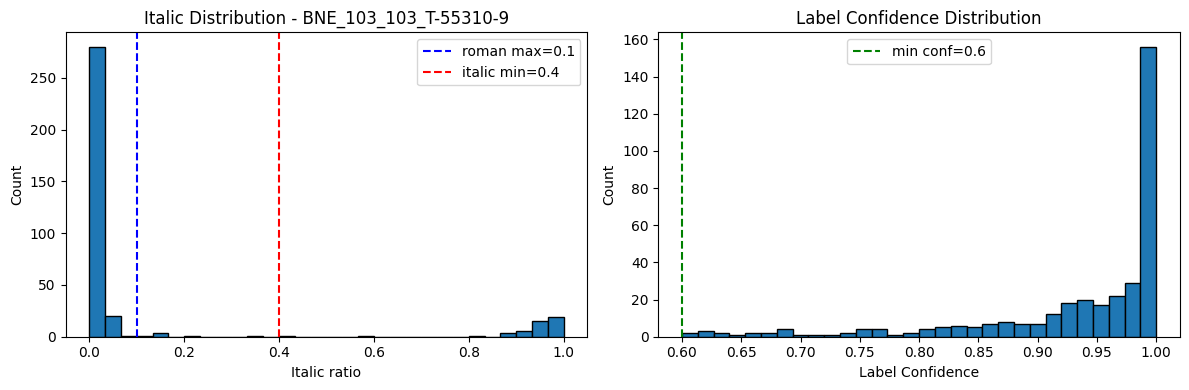

In [6]:
# Visualize italic distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(cluster_italic, bins=30, edgecolor='black')
ax1.axvline(CONFIG["roman"]["italic_max"], color='blue', linestyle='--', label=f'roman max={CONFIG["roman"]["italic_max"]}')
ax1.axvline(CONFIG["italic"]["italic_min"], color='red', linestyle='--', label=f'italic min={CONFIG["italic"]["italic_min"]}')
ax1.set_xlabel("Italic ratio")
ax1.set_ylabel("Count")
ax1.set_title(f"Italic Distribution - {sample_doc.name}")
ax1.legend()

# Label confidence distribution
confidences = [float(cl[1]) for cl in cluster_labels]
ax2.hist(confidences, bins=30, edgecolor='black')
ax2.axvline(CONFIG["filtering"]["label_confidence_min"], color='green', linestyle='--', 
            label=f'min conf={CONFIG["filtering"]["label_confidence_min"]}')
ax2.set_xlabel("Label Confidence")
ax2.set_ylabel("Count")
ax2.set_title("Label Confidence Distribution")
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Filter Clusters for Style

In [7]:
# Filter parameters
if STYLE == "roman":
    italic_max = CONFIG["roman"]["italic_max"]
    italic_min = None
else:
    italic_max = None
    italic_min = CONFIG["italic"]["italic_min"]

label_conf_min = CONFIG["filtering"]["label_confidence_min"]
top_n = CONFIG["filtering"]["top_clusters_per_letter"]
excluded = set(CONFIG["filtering"]["excluded_chars"])

print(f"Style: {STYLE}")
print(f"Italic threshold: max={italic_max}, min={italic_min}")
print(f"Label confidence min: {label_conf_min}")
print(f"Top clusters per letter: {top_n}")
print(f"Excluded chars: {excluded}")

Style: roman
Italic threshold: max=0.1, min=None
Label confidence min: 0.6
Top clusters per letter: 5
Excluded chars: {':', ',', ';', '.'}


In [8]:
# Apply filters to sample document
# Filter by style (italic ratio)
if STYLE == "roman":
    style_mask = cluster_italic <= italic_max
else:
    style_mask = cluster_italic >= italic_min

print(f"Clusters passing style filter: {style_mask.sum()} / {len(style_mask)}")

# Filter by label confidence
label_mask = np.array([float(cl[1]) >= label_conf_min for cl in cluster_labels])
print(f"Clusters passing confidence filter: {label_mask.sum()} / {len(label_mask)}")

# Combined mask
init_mask = style_mask & label_mask
print(f"Clusters passing both filters: {init_mask.sum()} / {len(init_mask)}")

Clusters passing style filter: 302 / 355
Clusters passing confidence filter: 355 / 355
Clusters passing both filters: 302 / 355


In [9]:
# Keep top N per letter
selected_labels = cluster_labels[init_mask][:, 0]
unique_letters = np.unique(selected_labels)
print(f"Unique letters after initial filter: {len(unique_letters)}")
print(f"Letters: {sorted(unique_letters)[:20]}...")

final_indices = []
init_indices = np.where(init_mask)[0]

for letter in unique_letters:
    if letter in excluded:
        continue
    
    letter_mask = selected_labels == letter
    letter_indices = init_indices[letter_mask]
    
    if len(letter_indices) > top_n:
        # Sort by sample count and keep top N
        counts = [int(cluster_labels[i][2]) for i in letter_indices]
        top_idx = np.argsort(counts)[-top_n:]
        letter_indices = letter_indices[top_idx]
    
    final_indices.extend(letter_indices)

print(f"\nFinal clusters after top-N filtering: {len(final_indices)}")

Unique letters after initial filter: 25
Letters: [np.str_('?'), np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('t')]...

Final clusters after top-N filtering: 101


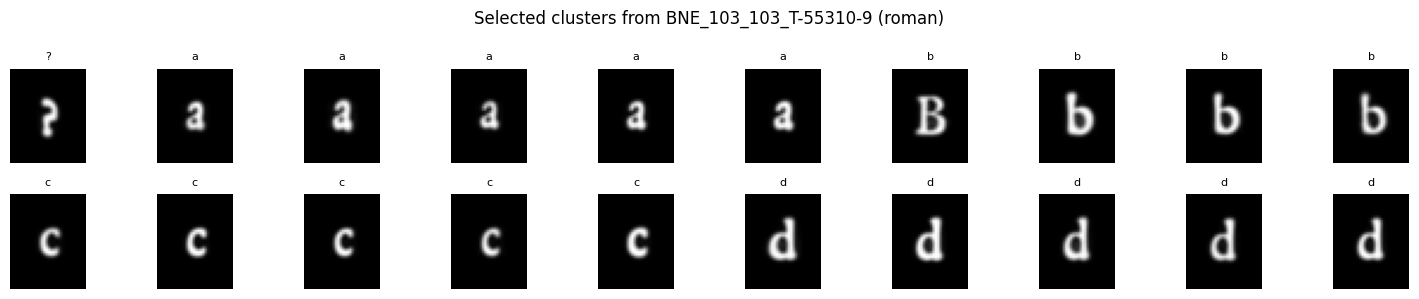

In [10]:
# Show selected clusters
n_show = min(20, len(final_indices))
fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i, idx in enumerate(final_indices[:n_show]):
    ax = axes.flat[i]
    ax.imshow(cluster_means[idx], cmap='gray')
    ax.set_title(f"{cluster_labels[idx][0]}", fontsize=8)
    ax.axis('off')

for i in range(n_show, 20):
    axes.flat[i].axis('off')

plt.suptitle(f"Selected clusters from {sample_doc.name} ({STYLE})")
plt.tight_layout()
plt.show()

## 6. Load All Documents

In [11]:
def load_clusters_for_style(charnet_dir, style, config):
    """Load and filter cluster data for a specific style."""
    filtering = config["filtering"]
    excluded = set(filtering["excluded_chars"])
    label_conf_min = filtering["label_confidence_min"]
    top_n = filtering["top_clusters_per_letter"]
    
    if style == "roman":
        italic_max = config["roman"]["italic_max"]
        italic_min = None
    else:
        italic_max = None
        italic_min = config["italic"]["italic_min"]
    
    mean_imgs = []
    labels = []
    names = []
    folders = []
    
    for doc_dir in sorted(charnet_dir.iterdir()):
        if not doc_dir.is_dir():
            continue
        
        cluster_path = doc_dir / "clusters_all.npz"
        if not cluster_path.exists():
            continue
        
        folders.append(doc_dir.name)
        
        try:
            data = np.load(str(cluster_path), allow_pickle=True)
        except Exception as e:
            print(f"Warning: Could not load {cluster_path}: {e}")
            continue
        
        cluster_means = data["cluster_means"]
        cluster_labels = data["cluster_labels"]
        cluster_italic = data["cluster_italic"]
        
        if len(cluster_italic) == 0:
            continue
        
        # Filter by style
        if style == "roman":
            style_mask = cluster_italic <= italic_max
        else:
            style_mask = cluster_italic >= italic_min
        
        # Filter by label confidence
        label_mask = np.array([float(cl[1]) >= label_conf_min for cl in cluster_labels])
        
        init_mask = style_mask & label_mask
        if not init_mask.any():
            continue
        
        selected_labels = cluster_labels[init_mask][:, 0]
        unique_letters = np.unique(selected_labels)
        final_indices = []
        init_indices = np.where(init_mask)[0]
        
        for letter in unique_letters:
            if letter in excluded:
                continue
            
            letter_mask = selected_labels == letter
            letter_indices = init_indices[letter_mask]
            
            if len(letter_indices) > top_n:
                counts = [int(cluster_labels[i][2]) for i in letter_indices]
                top_idx = np.argsort(counts)[-top_n:]
                letter_indices = letter_indices[top_idx]
            
            final_indices.extend(letter_indices)
        
        if not final_indices:
            continue
        
        for idx in final_indices:
            mean_imgs.append(cluster_means[idx])
            labels.append(cluster_labels[idx][0])
            names.append(doc_dir.name)
    
    return (
        np.array(mean_imgs) if mean_imgs else np.array([]),
        np.array(labels) if labels else np.array([]),
        np.array(names) if names else np.array([]),
        folders,
    )

In [12]:
# Load all clusters
mean_imgs, labels, names, folders = load_clusters_for_style(charnet_dir, STYLE, CONFIG)

print(f"Total clusters loaded: {len(mean_imgs)}")
print(f"Documents: {len(folders)}")
print(f"Unique letters: {len(np.unique(labels))}")

# Clusters per document
unique_names, counts = np.unique(names, return_counts=True)
print(f"\nClusters per document (first 10):")
for nm, cnt in list(zip(unique_names, counts))[:10]:
    print(f"  {nm}: {cnt}")

Total clusters loaded: 2241
Documents: 21
Unique letters: 27

Clusters per document (first 10):
  BNE_103_103_T-55310-9: 101
  BNE_119_117_T-55312-7: 109
  BNE_128_123_T-55318-14: 105
  BNE_164_163_T-55339-37: 103
  BNE_169_171_T-55328-22: 109
  BNE_201_201_T-55360-48: 104
  BNE_211_213_T-55360-60: 113
  BNE_212_216_T-55360-56: 103
  BNE_37_28_T-55360-53: 107
  BNE_429_193_T-55310-6: 104


## 7. Process a Single Letter (Detailed)

In [13]:
# Pick a common letter
from collections import Counter
letter_counts = Counter(labels)
print("Most common letters:")
for letter, count in letter_counts.most_common(15):
    print(f"  {letter!r}: {count}")

Most common letters:
  np.str_('a'): 105
  np.str_('c'): 105
  np.str_('d'): 105
  np.str_('e'): 105
  np.str_('f'): 105
  np.str_('i'): 105
  np.str_('l'): 105
  np.str_('m'): 105
  np.str_('n'): 105
  np.str_('o'): 105
  np.str_('p'): 105
  np.str_('r'): 105
  np.str_('s'): 105
  np.str_('u'): 105
  np.str_('t'): 103


In [14]:
# Select a letter to debug
DEBUG_LETTER = "a"  # EDIT THIS

mask = labels == DEBUG_LETTER
l_imgs = mean_imgs[mask].copy()
l_names = names[mask]

print(f"Letter '{DEBUG_LETTER}':")
print(f"  Total clusters: {len(l_imgs)}")
print(f"  Documents: {len(np.unique(l_names))}")

# Check document coverage
n_docs = len(folders)
coverage = len(np.unique(l_names)) / n_docs
min_coverage = CONFIG["filtering"]["min_doc_coverage"]
print(f"  Coverage: {coverage:.2%} (min required: {min_coverage:.2%})")
print(f"  Will be {'INCLUDED' if coverage >= min_coverage else 'EXCLUDED'}")

Letter 'a':
  Total clusters: 105
  Documents: 21
  Coverage: 100.00% (min required: 33.00%)
  Will be INCLUDED


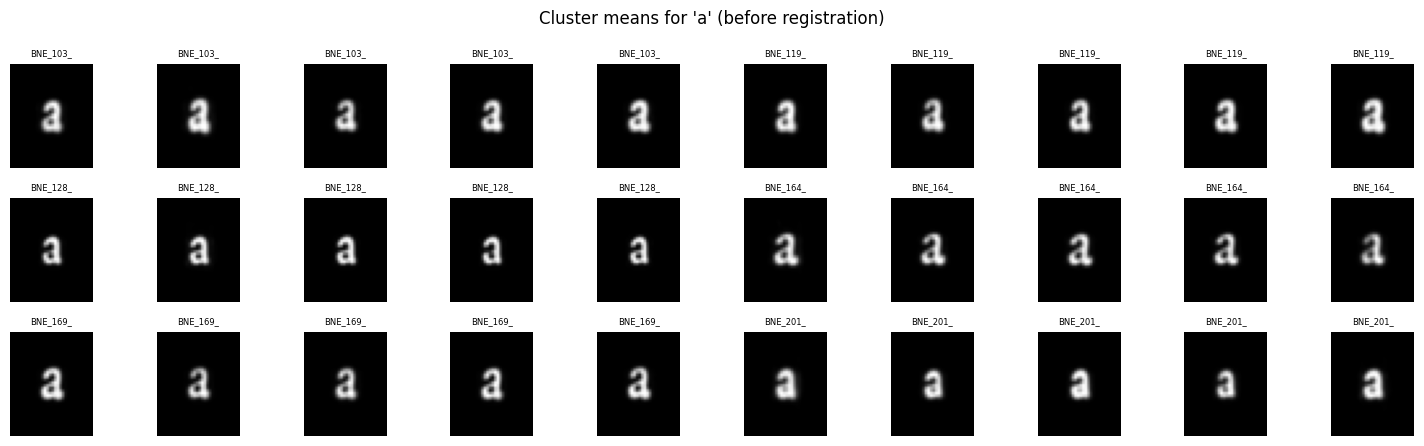

In [15]:
# Show cluster means for this letter
n_show = min(30, len(l_imgs))
cols = 10
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 1.5 * rows))

for i in range(n_show):
    ax = axes.flat[i]
    ax.imshow(l_imgs[i], cmap='gray')
    ax.set_title(l_names[i][:8], fontsize=6)
    ax.axis('off')

for i in range(n_show, rows * cols):
    axes.flat[i].axis('off')

plt.suptitle(f"Cluster means for '{DEBUG_LETTER}' (before registration)")
plt.tight_layout()
plt.show()

## 8. Register to Mean

In [16]:
# Register images
transform = CONFIG["registration"]["transform"]
print(f"Transform: {transform}")


tf_means = register2mean(l_imgs, transform=transform)

Transform: euclidean


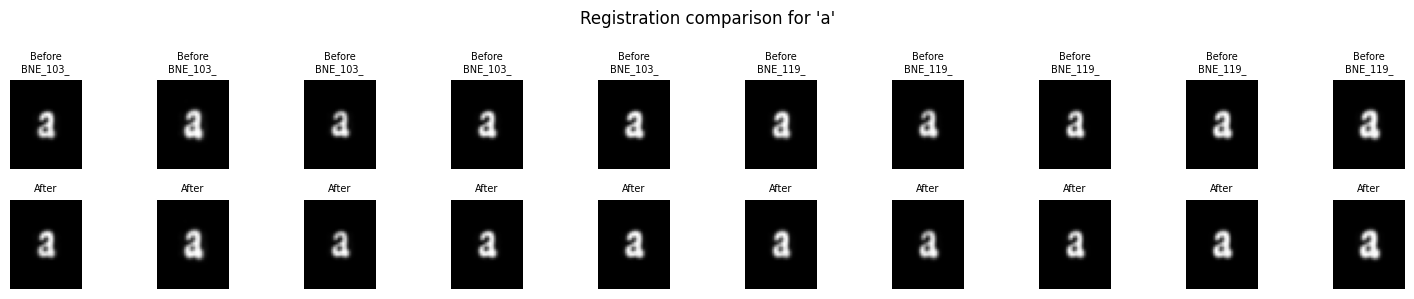

In [17]:
# Compare before/after registration
n_compare = min(10, len(l_imgs))
fig, axes = plt.subplots(2, n_compare, figsize=(15, 3))

for i in range(n_compare):
    axes[0, i].imshow(l_imgs[i], cmap='gray')
    axes[0, i].set_title(f"Before\n{l_names[i][:8]}", fontsize=7)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(tf_means[i], cmap='gray')
    axes[1, i].set_title("After", fontsize=7)
    axes[1, i].axis('off')

plt.suptitle(f"Registration comparison for '{DEBUG_LETTER}'")
plt.tight_layout()
plt.show()

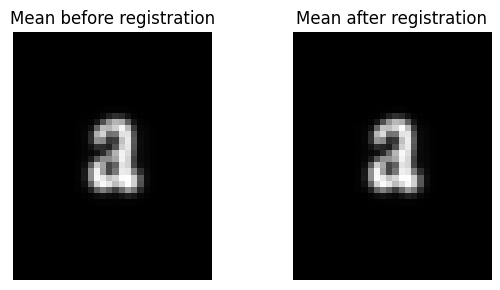

In [18]:
# Show mean before/after registration
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

ax1.imshow(l_imgs.mean(axis=0), cmap='gray')
ax1.set_title("Mean before registration")
ax1.axis('off')

ax2.imshow(tf_means.mean(axis=0), cmap='gray')
ax2.set_title("Mean after registration")
ax2.axis('off')

plt.tight_layout()
plt.show()

## 9. Compute Pairwise Distances

In [19]:
# Compute pairwise distances
metric = CONFIG["distance"]["metric"]
print(f"Metric: {metric}")

p_dist = pairwise_distances(
    tf_means.reshape(len(tf_means), -1),
    metric=metric
)

print(f"Distance matrix shape: {p_dist.shape}")
print(f"Min distance: {p_dist[p_dist > 0].min():.4f}")
print(f"Max distance: {p_dist.max():.4f}")
print(f"Mean distance: {p_dist[p_dist > 0].mean():.4f}")

Metric: cosine
Distance matrix shape: (105, 105)
Min distance: 0.0004
Max distance: 0.1411
Mean distance: 0.0314


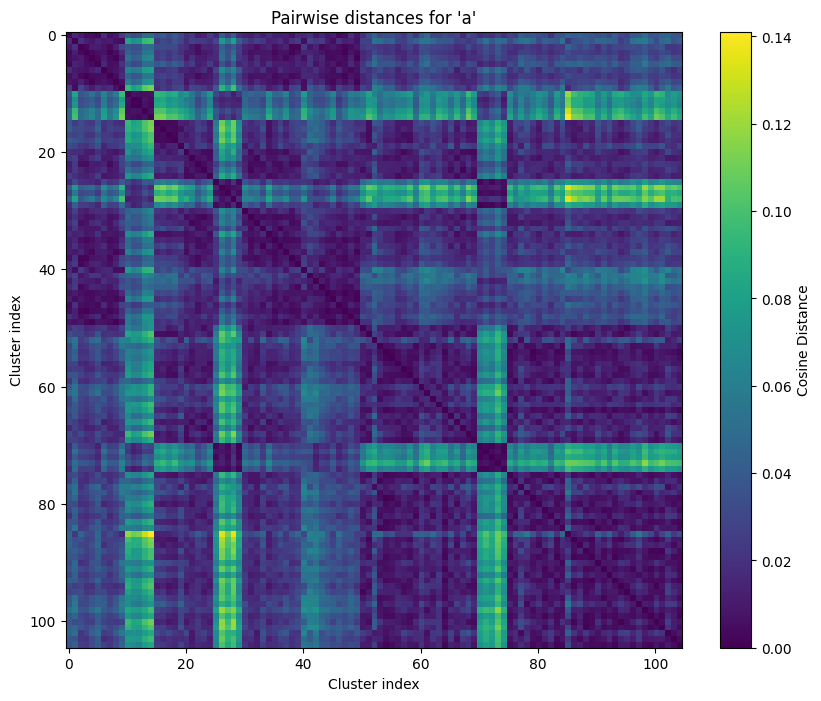

In [20]:
# Visualize distance matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(p_dist, cmap='viridis')
plt.colorbar(im, ax=ax, label='Cosine Distance')
ax.set_title(f"Pairwise distances for '{DEBUG_LETTER}'")
ax.set_xlabel("Cluster index")
ax.set_ylabel("Cluster index")
plt.show()

## 10. Aggregate to Per-Document Distances

In [21]:
def per_doc_inf(distances, y_names):
    """Aggregate pairwise distances to per-document minimum distances."""
    distances_df = pd.DataFrame(distances, index=y_names, columns=y_names)
    
    idx = np.unique(y_names, return_index=True)[1]
    unique_names = np.array([y_names[index] for index in sorted(idx)])
    n = len(unique_names)
    
    agg_distances = np.zeros((n, n))
    arg_mins = np.zeros((n, n, 2), dtype=int)
    
    for i in range(n - 1):
        for j in range(i + 1, n):
            dist = distances_df.loc[[unique_names[i]], [unique_names[j]]].values
            agg_distances[i, j] = dist.min(1).min()
            agg_distances[j, i] = dist.min(0).min()
            arg_mins[i, j] = np.unravel_index(dist.argmin(), dist.shape)
    
    return agg_distances, arg_mins, unique_names

In [22]:
# Aggregate
distances_cos, arg_mins, unique_doc_names = per_doc_inf(p_dist, l_names)
distances_cos = (distances_cos + distances_cos.T) / 2  # Symmetrize

print(f"Per-document distance matrix shape: {distances_cos.shape}")
print(f"Documents: {len(unique_doc_names)}")

Per-document distance matrix shape: (21, 21)
Documents: 21


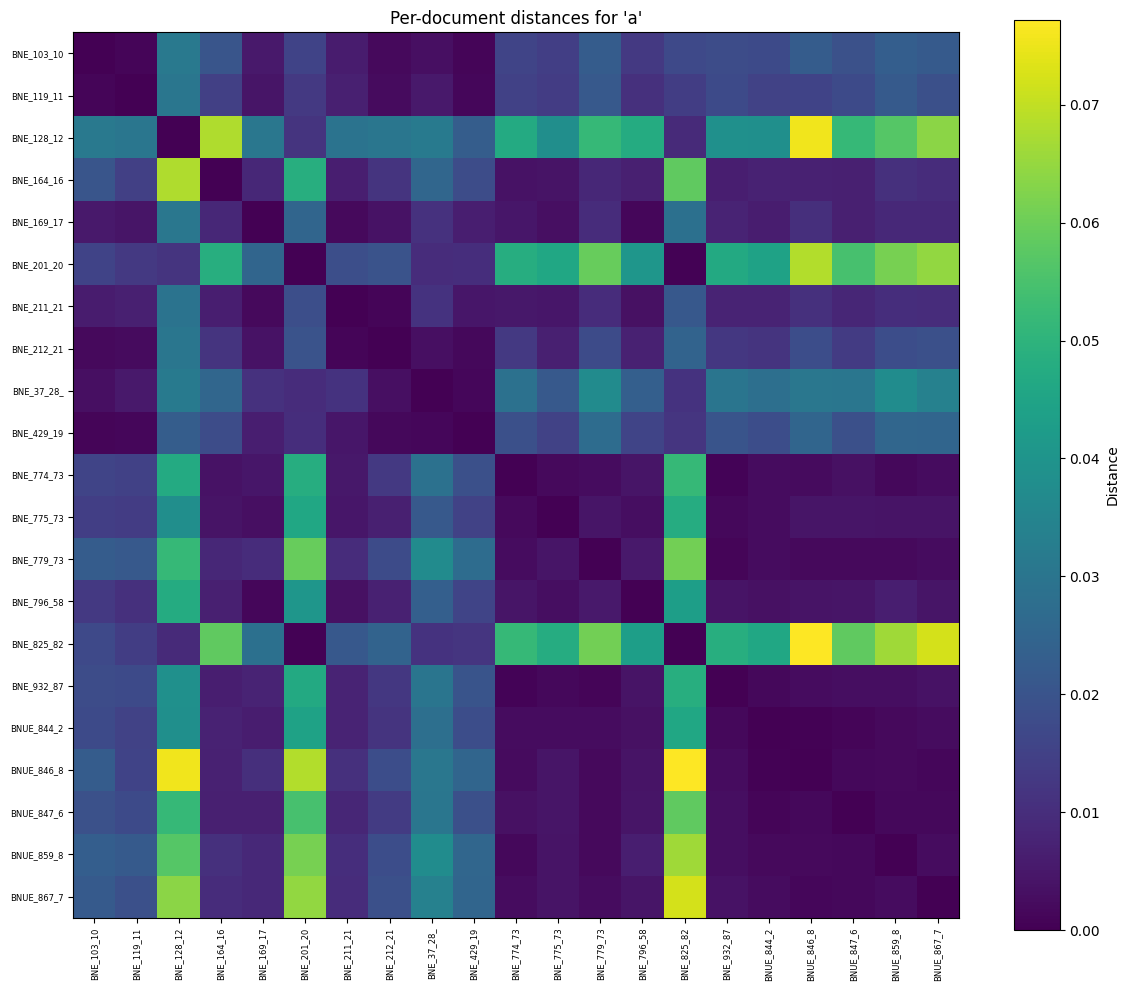

In [23]:
# Visualize per-document distances
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(distances_cos, cmap='viridis')
plt.colorbar(im, ax=ax, label='Distance')

# Add labels if not too many
if len(unique_doc_names) <= 30:
    ax.set_xticks(range(len(unique_doc_names)))
    ax.set_yticks(range(len(unique_doc_names)))
    ax.set_xticklabels([n[:10] for n in unique_doc_names], rotation=90, fontsize=6)
    ax.set_yticklabels([n[:10] for n in unique_doc_names], fontsize=6)

ax.set_title(f"Per-document distances for '{DEBUG_LETTER}'")
plt.tight_layout()
plt.show()

## 11. Build Full Adjacency Matrix (All Letters)

In [24]:
def compute_all_distances(mean_imgs, labels, names, folders, config):
    """Compute per-letter adjacency matrices."""
    filtering = config["filtering"]
    excluded = set(filtering["excluded_chars"])
    min_coverage = filtering["min_doc_coverage"]
    transform = config["registration"]["transform"]
    metric = config["distance"]["metric"]
    
    all_letters = np.unique(labels)
    all_letters = [l for l in all_letters if l not in excluded]
    
    n_docs = len(folders)
    Adj = np.zeros((len(all_letters), n_docs, n_docs))
    valid_letters = []
    skipped_letters = []
    
    for l_idx, letter in enumerate(all_letters):
        mask = labels == letter
        uq_names = np.unique(names[mask])
        
        # Check minimum document coverage
        if len(uq_names) < (n_docs * min_coverage):
            skipped_letters.append((letter, len(uq_names), n_docs * min_coverage))
            continue
        
        valid_letters.append(letter)
        
        # Get images for this letter
        l_imgs = mean_imgs[mask].copy()
        l_names = names[mask]
        
        # Register to mean
        tf_means = register2mean(l_imgs, transform=transform)
            
        # plot tf_means for debugging
        fig, axes = plt.subplots(1, min(10, len(tf_means)), figsize=(15, 3))
        for i in range(min(10, len(tf_means))):
            axes[i].imshow(tf_means[i], cmap='gray')
            axes[i].set_title(f"{l_names[i][:8]}", fontsize=6)
            axes[i].axis('off')
        plt.suptitle(f"Registered means for letter '{letter}'")
        plt.tight_layout()
        plt.show()
        
        # Compute pairwise distances
        p_dist = pairwise_distances(
            tf_means.reshape(len(tf_means), -1),
            metric=metric
        )
        
        # Aggregate to per-document distances
        distances_cos, _, _ = per_doc_inf(p_dist, l_names)
        distances_cos = (distances_cos + distances_cos.T) / 2
        
        # Fill adjacency matrix
        Adj[l_idx] += 2 * distances_cos.max()
        
        for k, nm_0 in enumerate(uq_names):
            i = np.where(np.array(folders) == nm_0)[0]
            if len(i) == 0:
                continue
            i = i[0]
            
            for m, nm_1 in enumerate(uq_names[k + 1:]):
                j = np.where(np.array(folders) == nm_1)[0]
                if len(j) == 0:
                    continue
                j = j[0]
                
                Adj[l_idx, i, j] += distances_cos[k, m + k + 1] - (2 * distances_cos.max())
                Adj[l_idx, j, i] += distances_cos[k, m + k + 1] - (2 * distances_cos.max())
    
    # Remove letters with all zeros
    row_sums = Adj.sum(axis=(1, 2))
    nonzero_rows = row_sums != 0
    Adj = Adj[nonzero_rows]
    
    return Adj, valid_letters, skipped_letters

Computing distances for all letters...


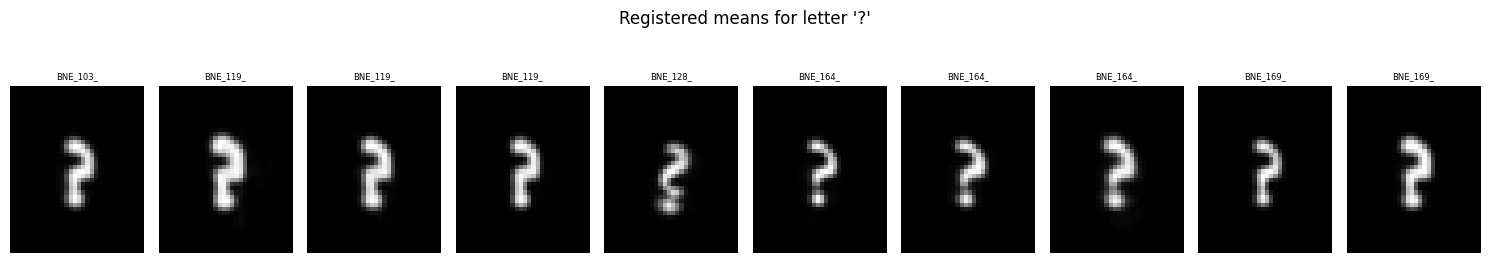

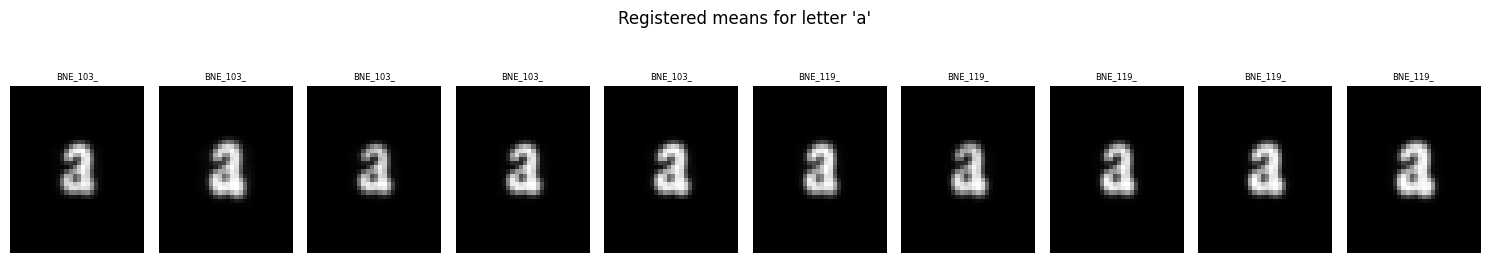

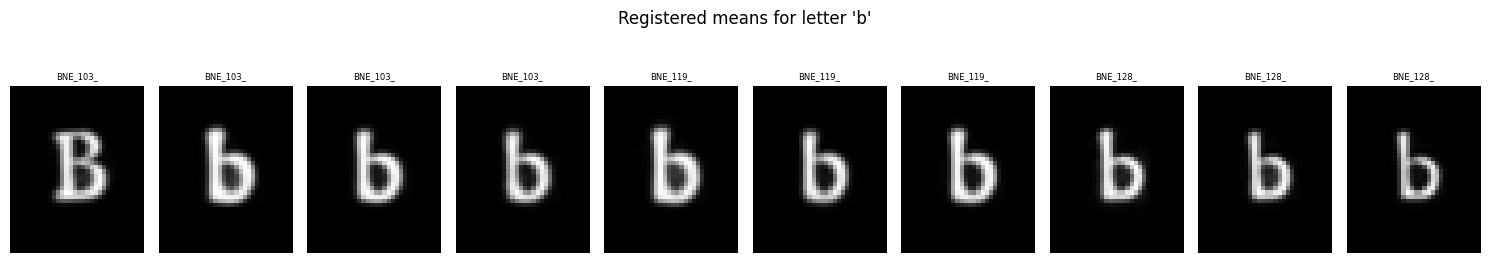

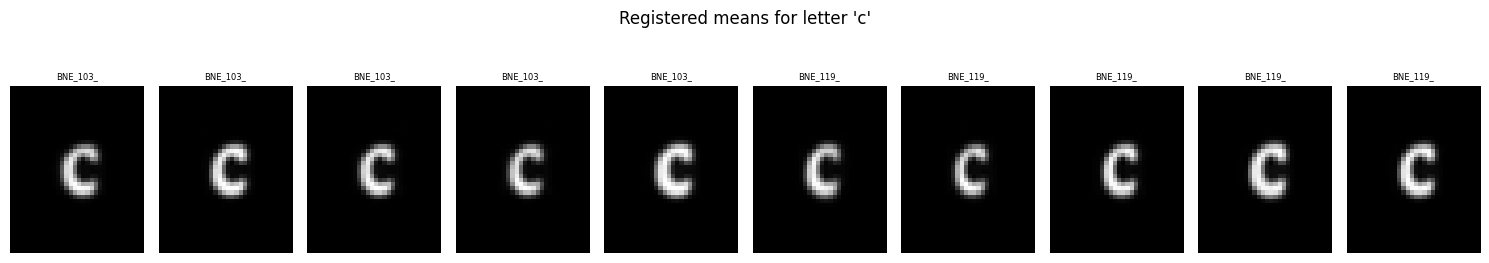

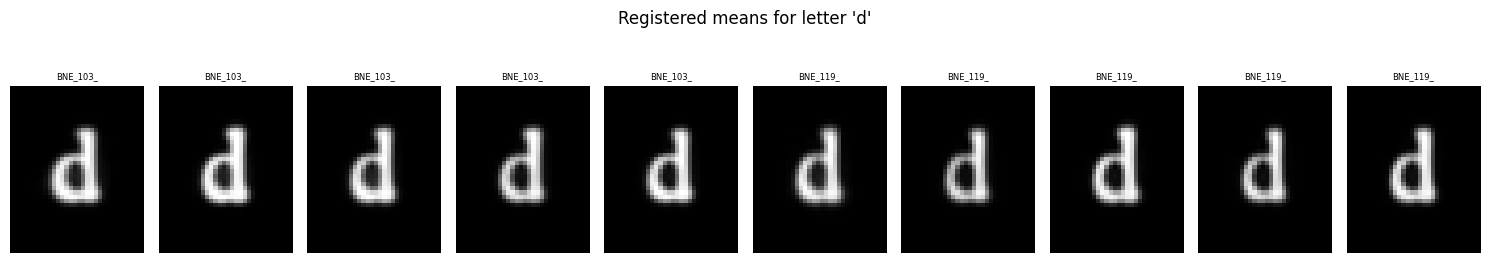

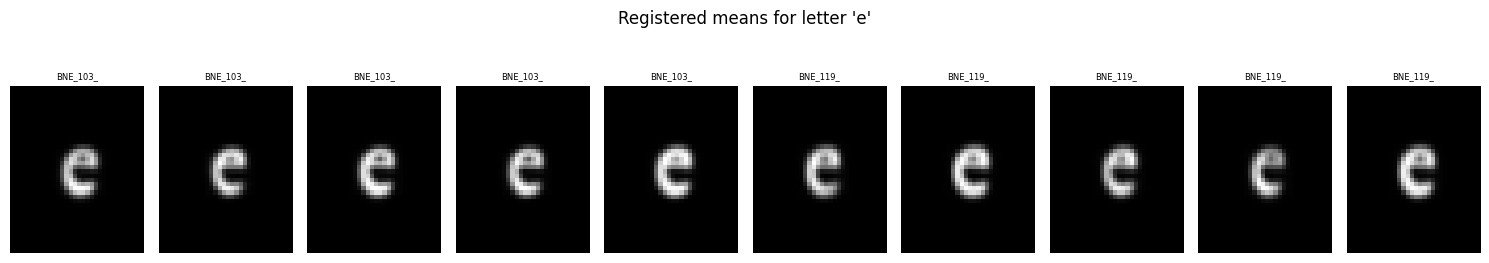

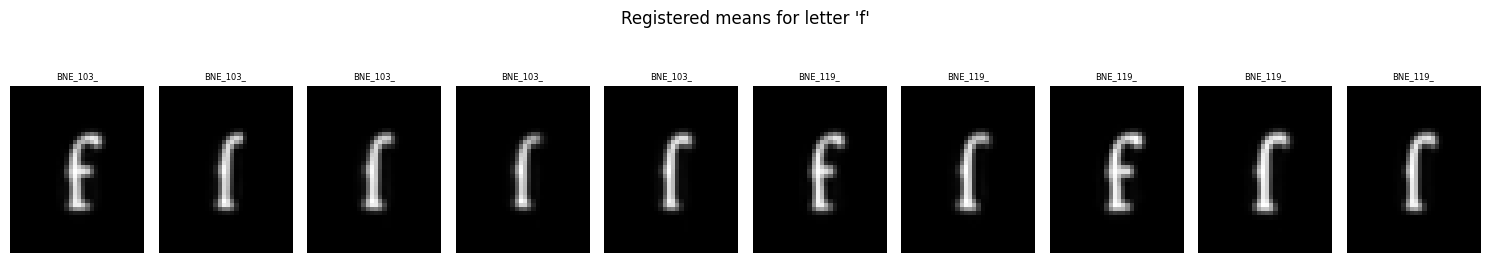

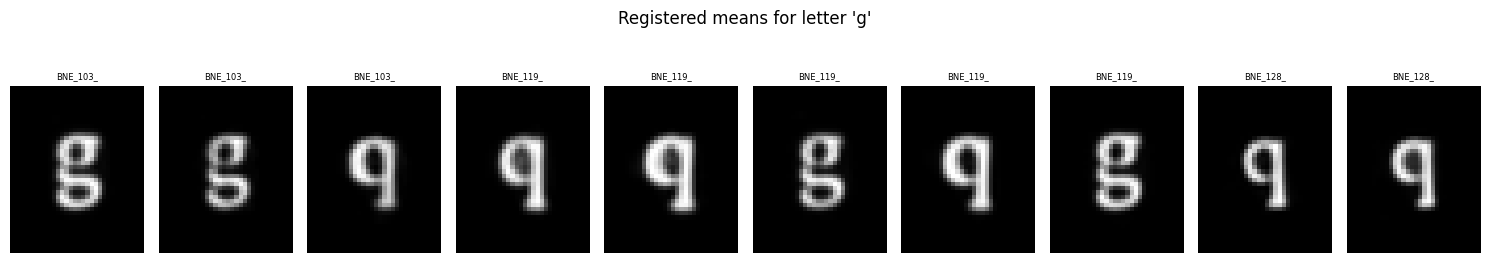

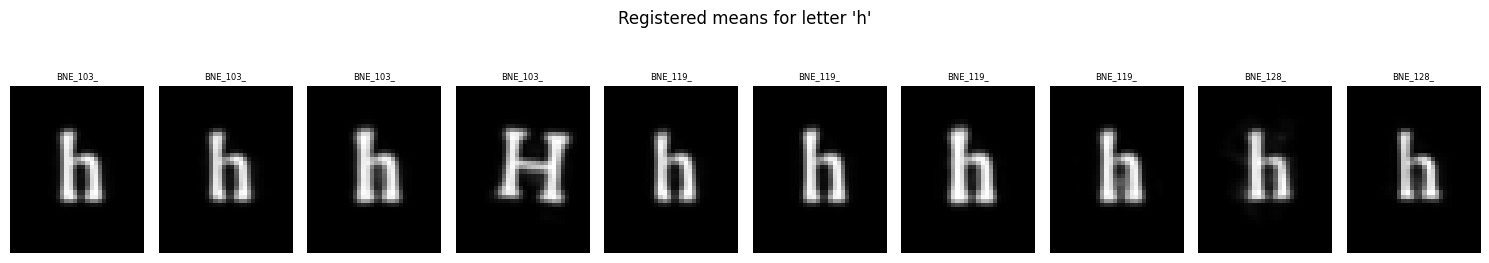

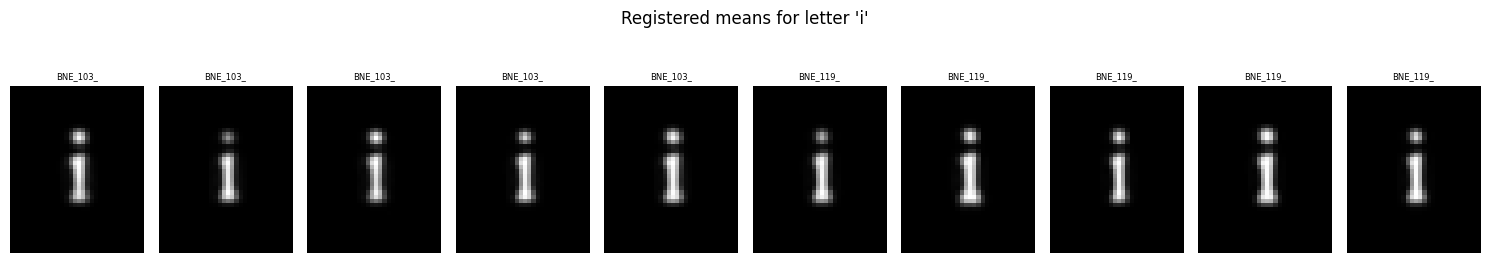

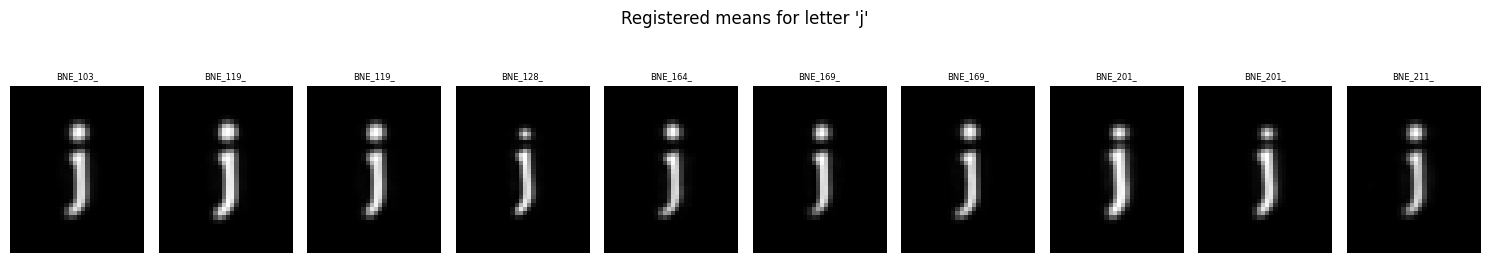

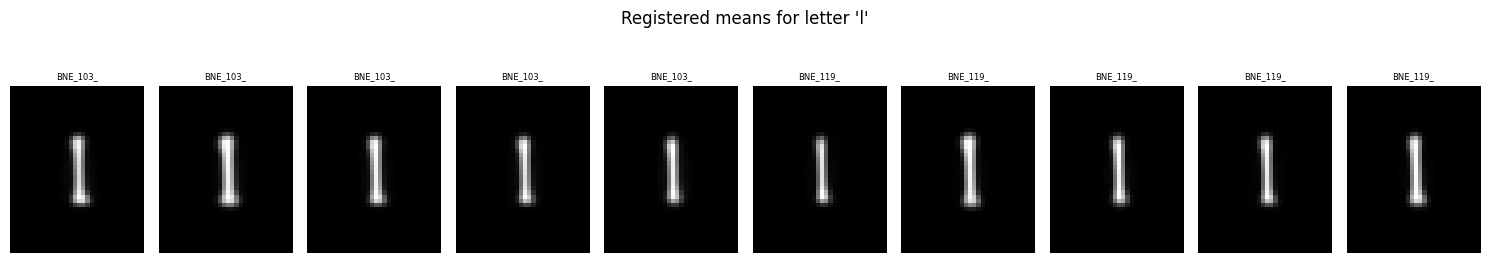

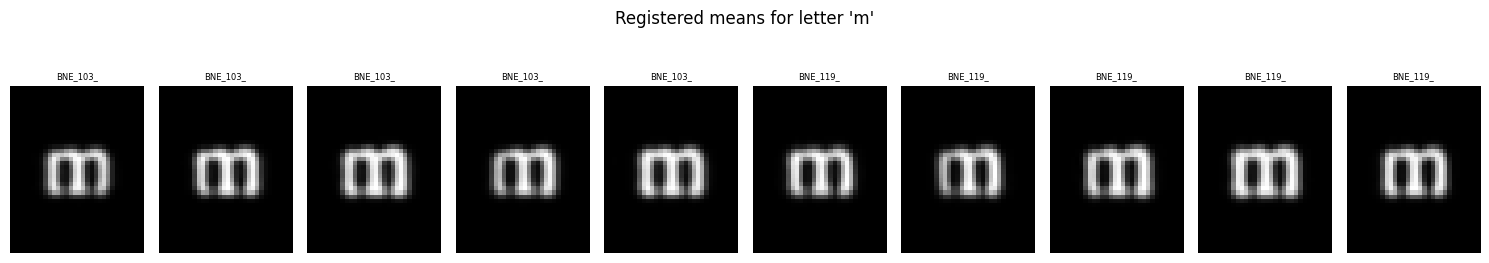

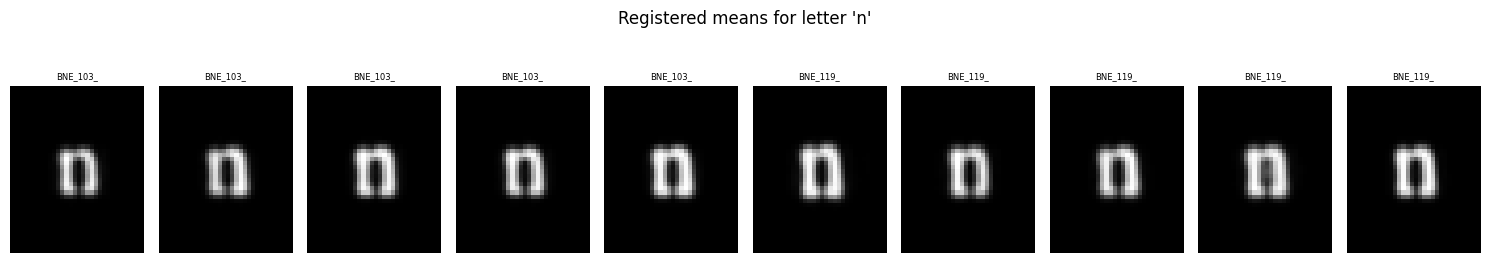

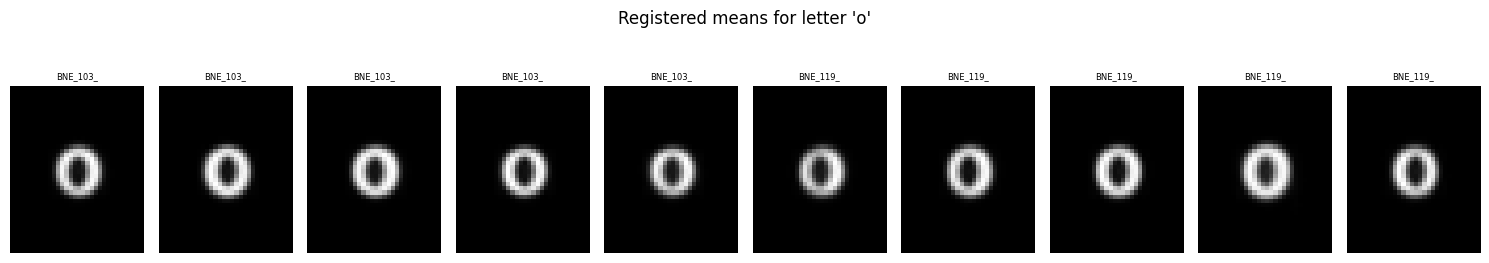

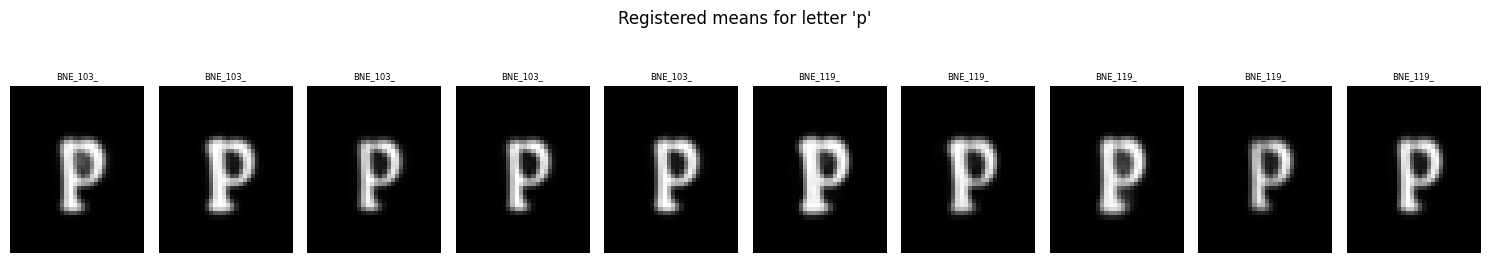

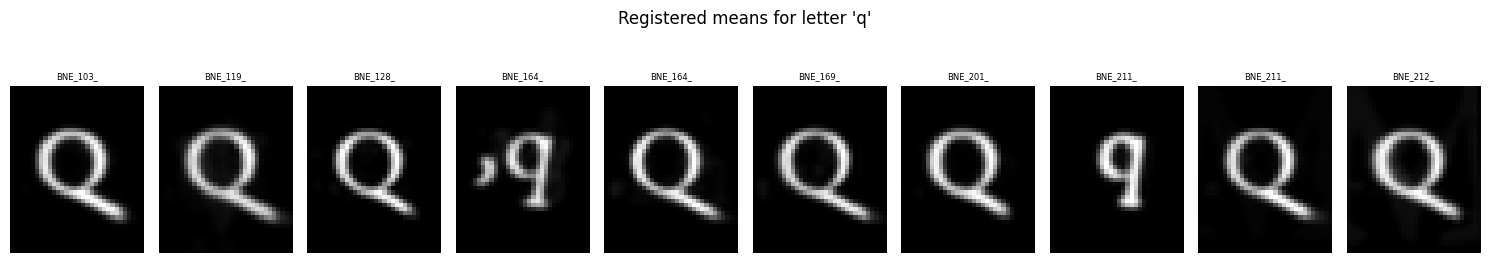

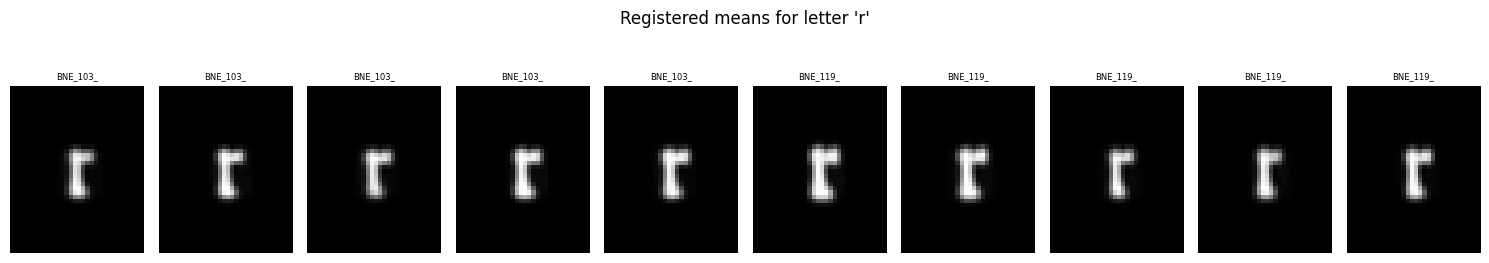

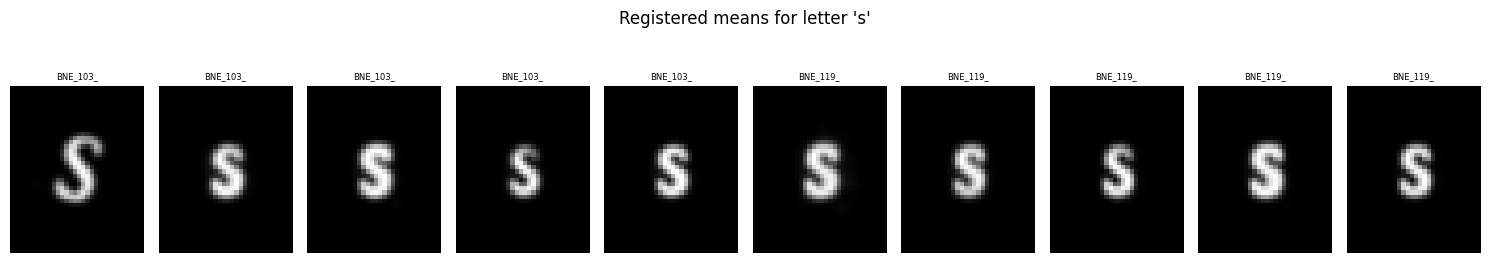

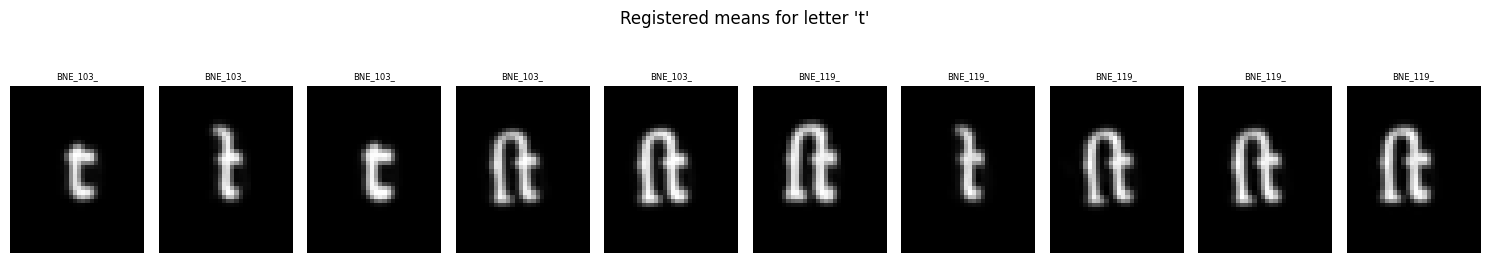

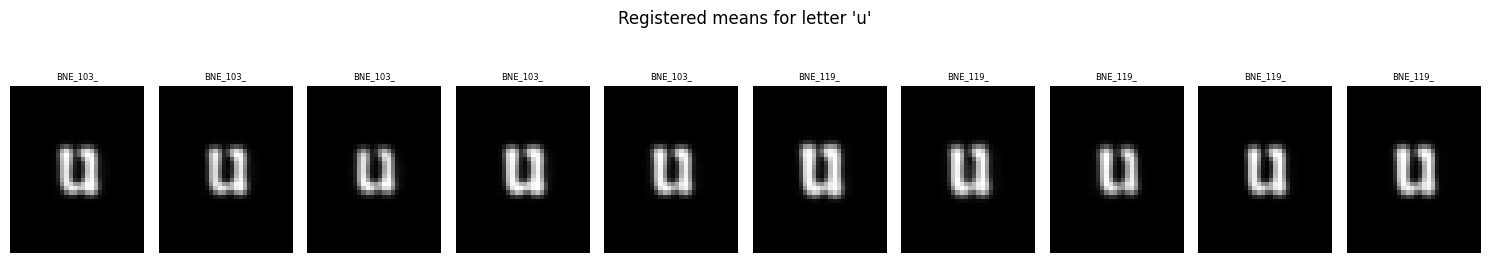

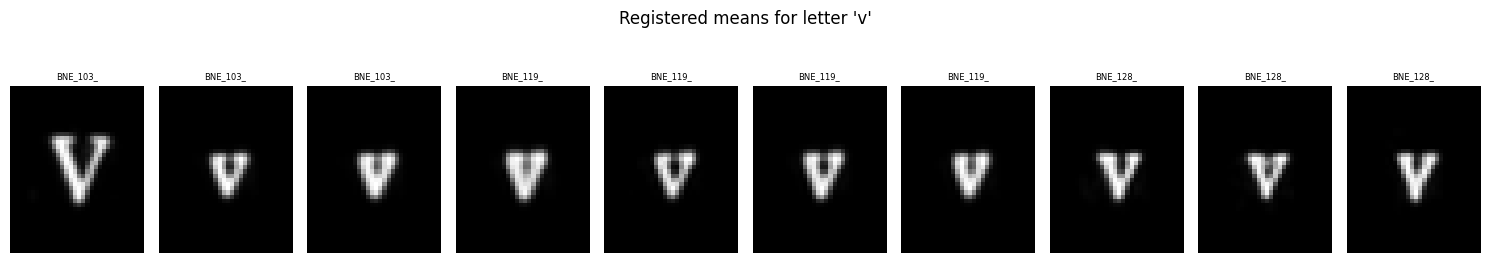

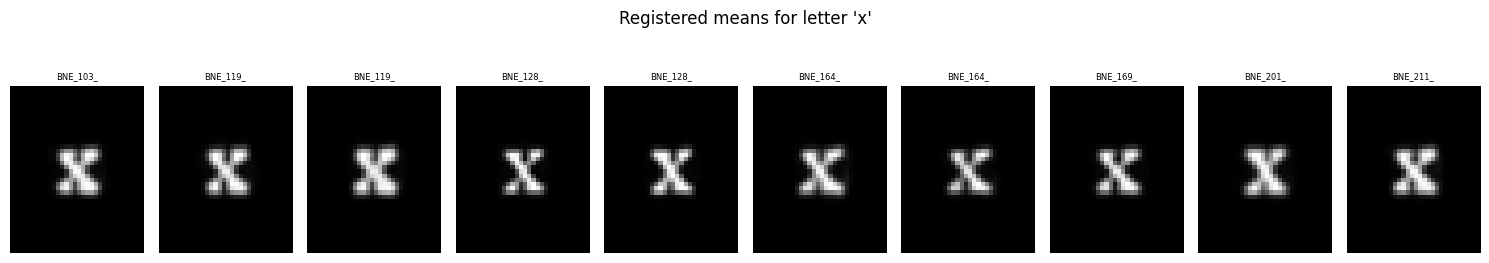

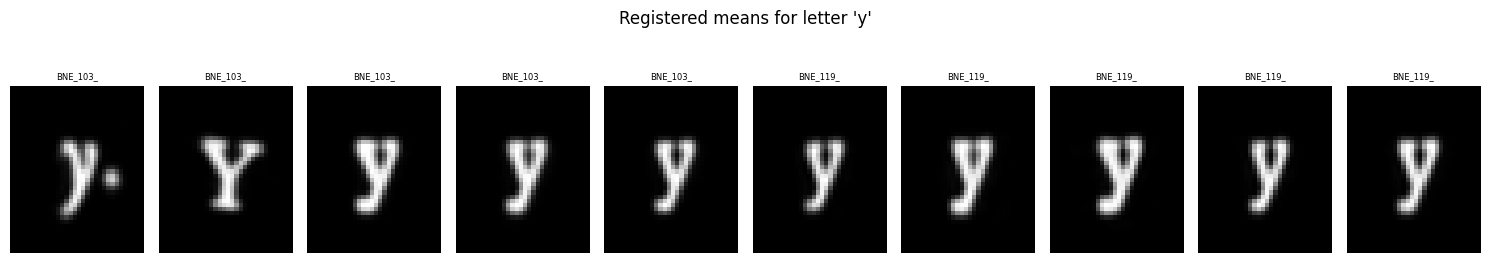

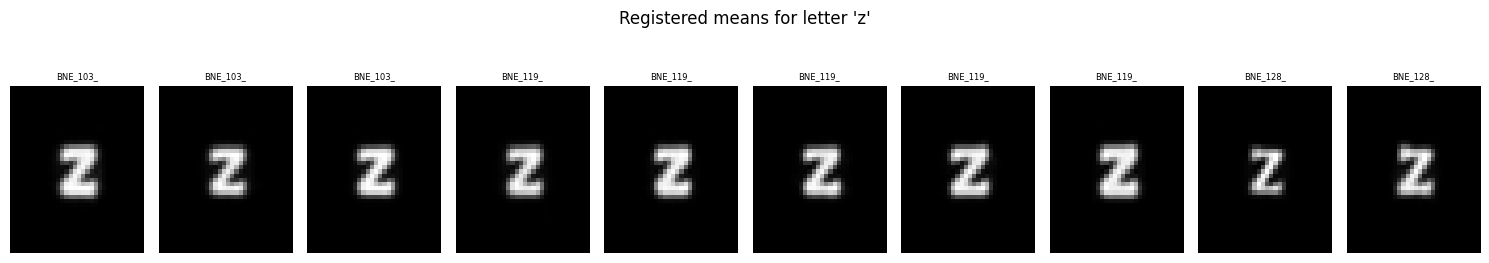


Adjacency matrix shape: (25, 21, 21)
Valid letters: 25
Skipped letters: 2


In [25]:
# Compute all distances (this may take a while)
print("Computing distances for all letters...")
Adj, valid_letters, skipped_letters = compute_all_distances(
    mean_imgs, labels, names, folders, CONFIG
)

print(f"\nAdjacency matrix shape: {Adj.shape}")
print(f"Valid letters: {len(valid_letters)}")
print(f"Skipped letters: {len(skipped_letters)}")

In [26]:
# Show skipped letters and why
print("Skipped letters (low document coverage):")
for letter, n_docs_with, min_required in skipped_letters[:15]:
    print(f"  '{letter}': {n_docs_with} docs (required: {min_required:.1f})")

Skipped letters (low document coverage):
  '!': 4 docs (required: 6.9)
  '(': 2 docs (required: 6.9)


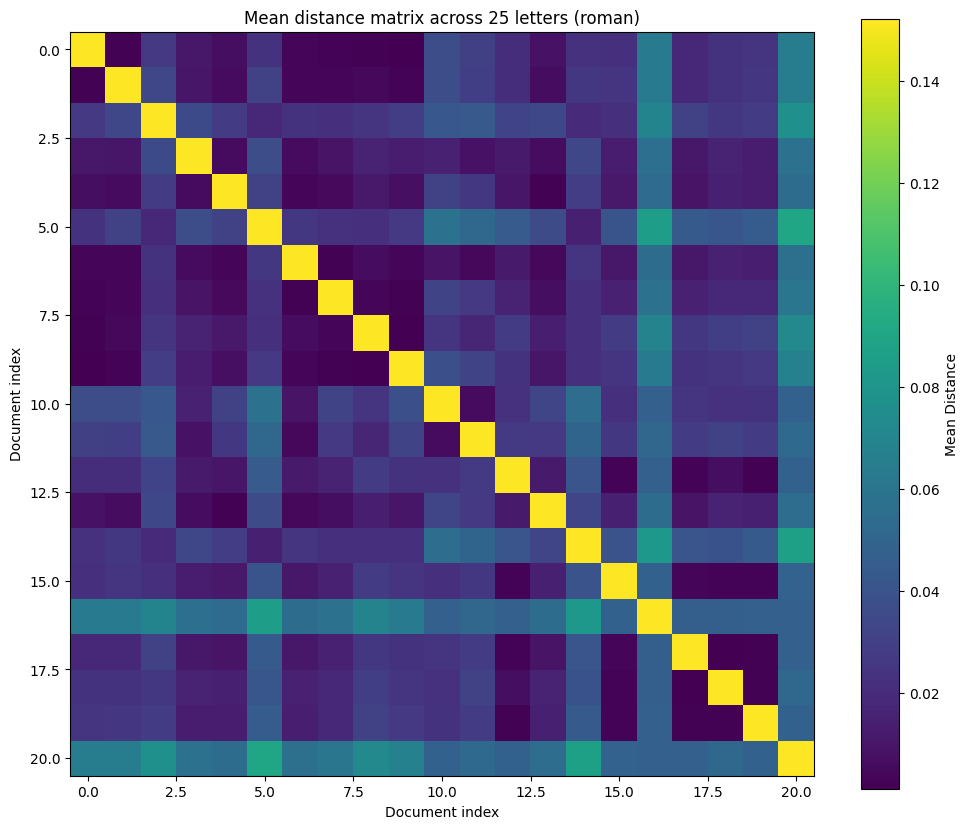

In [27]:
# Aggregate across letters (mean)
mean_adj = Adj[:].mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(mean_adj, cmap='viridis')
plt.colorbar(im, ax=ax, label='Mean Distance')
ax.set_title(f"Mean distance matrix across {len(valid_letters)} letters ({STYLE})")
ax.set_xlabel("Document index")
ax.set_ylabel("Document index")
plt.show()